### Convex optimizations with noise

In this notebook, we will test how the models behave on functions with noise.

In [27]:
import gymnasium as gym
import seaborn as sns
import matplotlib.pyplot as plt
import src.gymnasium_envs.convex_optimization_env
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
from src.optimization.convex_function import ConvexFunction
from src.optimization.convex_function_w_noise import ConvexFunctionWithNoise
from src.optimization.optimization_methods import gradient_descent_optimizer, adam_optimizer

seed = 42

Let's test the 2d model on a problem with noise against standard methods

In [28]:
env = make_vec_env(
    "convex_optimization_env/ConvexOptimization-v0",
    n_envs=1,
    seed=seed,
    env_kwargs={
        "render_mode": "ansi",
        "in_features": 2,
        "add_noise" : True
    }
)

env = VecNormalize.load("../models/2d_convex_optimization_vec_normalize_stats.pkl", env)

env.training = False
env.norm_reward = False 

model = PPO.load("../models/2d_convex_optimization", env=env, seed=seed)

obs = env.reset()

x0 = env.envs[0].unwrapped.get_x_start()

func = env.envs[0].unwrapped.get_function()

rl_gd_info = [[{
    'iteration': 0, 
    'function_value': func(x0), 
    'x': x0.copy()
}]]

In [29]:
done = False

while not done:
    action, _states = model.predict(obs, deterministic=True)
    
    obs, reward, terminated, info = env.step(action)
    
    rl_gd_info.append(info)

    done = terminated

Now using default gradient methods

In [30]:
function = ConvexFunctionWithNoise(in_features=2, random_state=seed)

gd_info = []
adam_info = []

gradient_descent_optimizer(function, x0=x0, opt_info=gd_info)
adam_optimizer(function, x0=x0, opt_info=adam_info)

OptimizeResult(iteration_count=4609, x_start=array([ 0.5479121 , -0.12224312]), x_best=array([0.16852517, 0.40482231]), function_value=np.float64(0.8407012918959713), grad_norm=np.float64(0.0010062254135297973), grad_delta_norm=np.float64(6.95529946405465e-06), status=1)

Let's visualize standard methods

In [31]:
gd_it, gd_val = zip(*[(item['iteration'], item['function_value']) for item in gd_info])
adam_it, adam_val = zip(*[(item['iteration'], item['function_value']) for item in adam_info])
rl_gd_it, rl_gd_val = zip(*[(item[0]['iteration'], item[0]['function_value']) for item in rl_gd_info[:-2]])

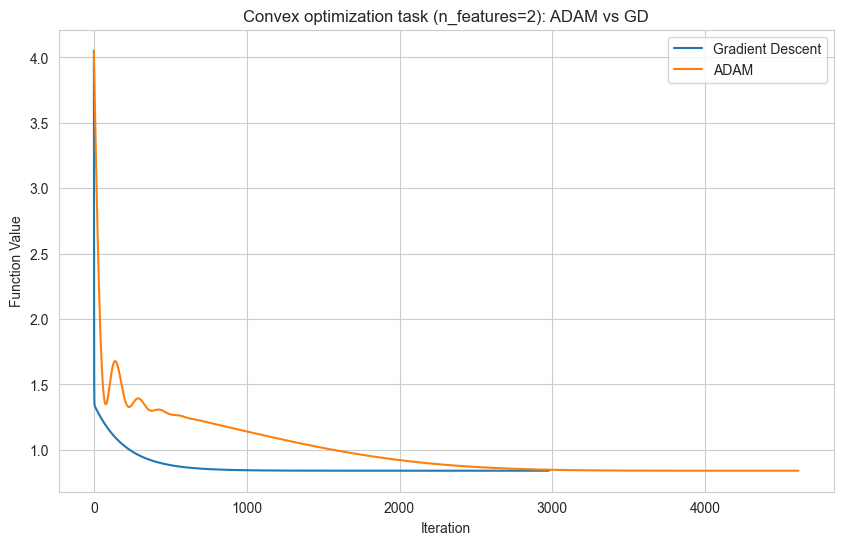

In [32]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(x=gd_it, y=gd_val, label='Gradient Descent')
sns.lineplot(x=adam_it, y=adam_val, label='ADAM')

plt.title('Convex optimization task (n_features=2): ADAM vs GD')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.legend()
plt.show()

Now let's visualize algorithm trained on convex problem

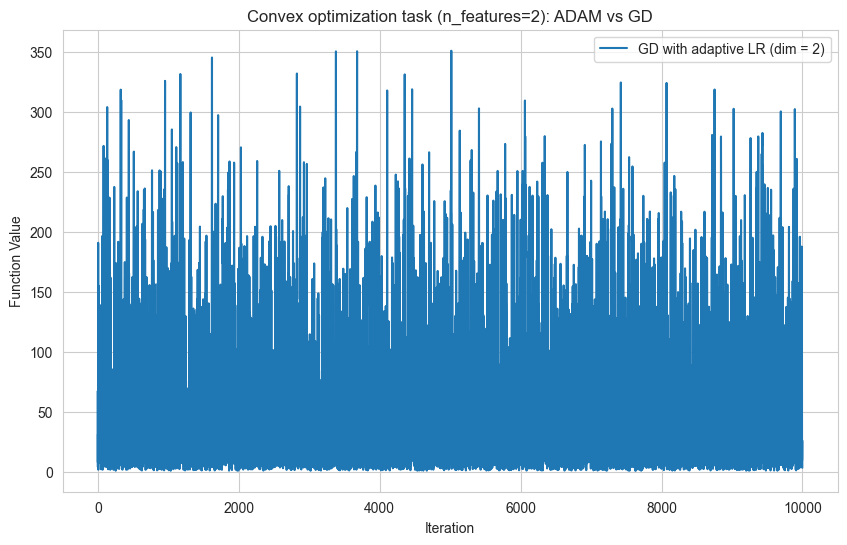

In [33]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(x=rl_gd_it, y=rl_gd_val, label='GD with adaptive LR (dim = 2)')


plt.title('Convex optimization task (n_features=2): ADAM vs GD')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.legend()
plt.show()

As we see our PPO model that was trained only on convex problem has beed broken

Now we trained another model with noise

In [34]:
env = make_vec_env(
    "convex_optimization_env/ConvexOptimization-v0",
    n_envs=1,
    seed=seed,
    env_kwargs={
        "render_mode": "ansi",
        "in_features": 2,
        "add_noise" : True
    }
)

env = VecNormalize.load("../models/2d_convex_w_noise_optimization_vec_normalize_stats.pkl", env)

env.training = False
env.norm_reward = False 

model = PPO.load("../models/2d_convex_w_noise_optimization", env=env, seed=seed)

obs = env.reset()

x0 = env.envs[0].unwrapped.get_x_start()

func = env.envs[0].unwrapped.get_function()

rl_gd_info = [[{
    'iteration': 0, 
    'function_value': func(x0), 
    'x': x0.copy()
}]]

In [35]:
done = False

while not done:
    action, _states = model.predict(obs, deterministic=True)
    
    obs, reward, terminated, info = env.step(action)
    
    rl_gd_info.append(info)

    done = terminated

In [36]:
gd_it, gd_val = zip(*[(item['iteration'], item['function_value']) for item in gd_info])
adam_it, adam_val = zip(*[(item['iteration'], item['function_value']) for item in adam_info])
rl_gd_it, rl_gd_val = zip(*[(item[0]['iteration'], item[0]['function_value']) for item in rl_gd_info[:-2]])

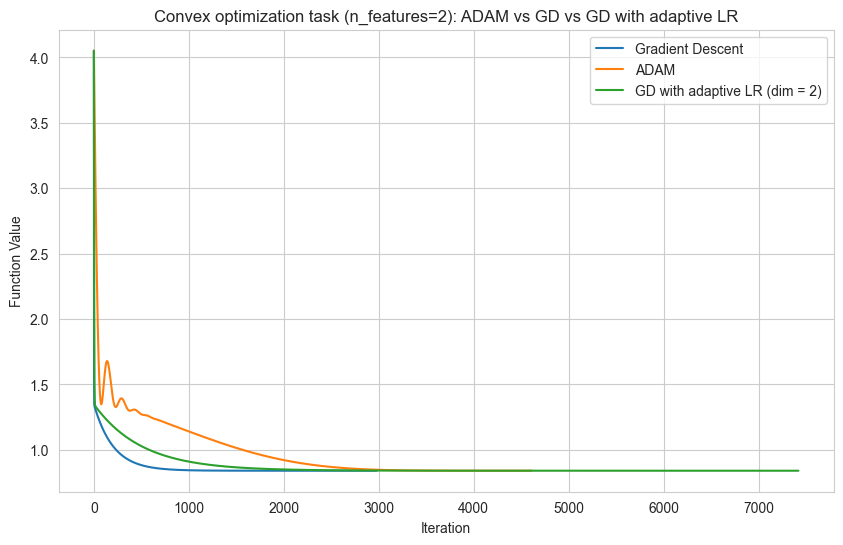

In [37]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(x=gd_it, y=gd_val, label='Gradient Descent')
sns.lineplot(x=adam_it, y=adam_val, label='ADAM')
sns.lineplot(x=rl_gd_it, y=rl_gd_val, label='GD with adaptive LR (dim = 2)')

plt.title('Convex optimization task (n_features=2): ADAM vs GD vs GD with adaptive LR')
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.legend()
plt.show()